# Logistic Regression
- https://easy.prag-ai.com/slide/img03/1

## 분류에 사용한다. (Classification)

예) 나이대별로 이메일을 클릭해서 열지 말지를 분류해 보자.

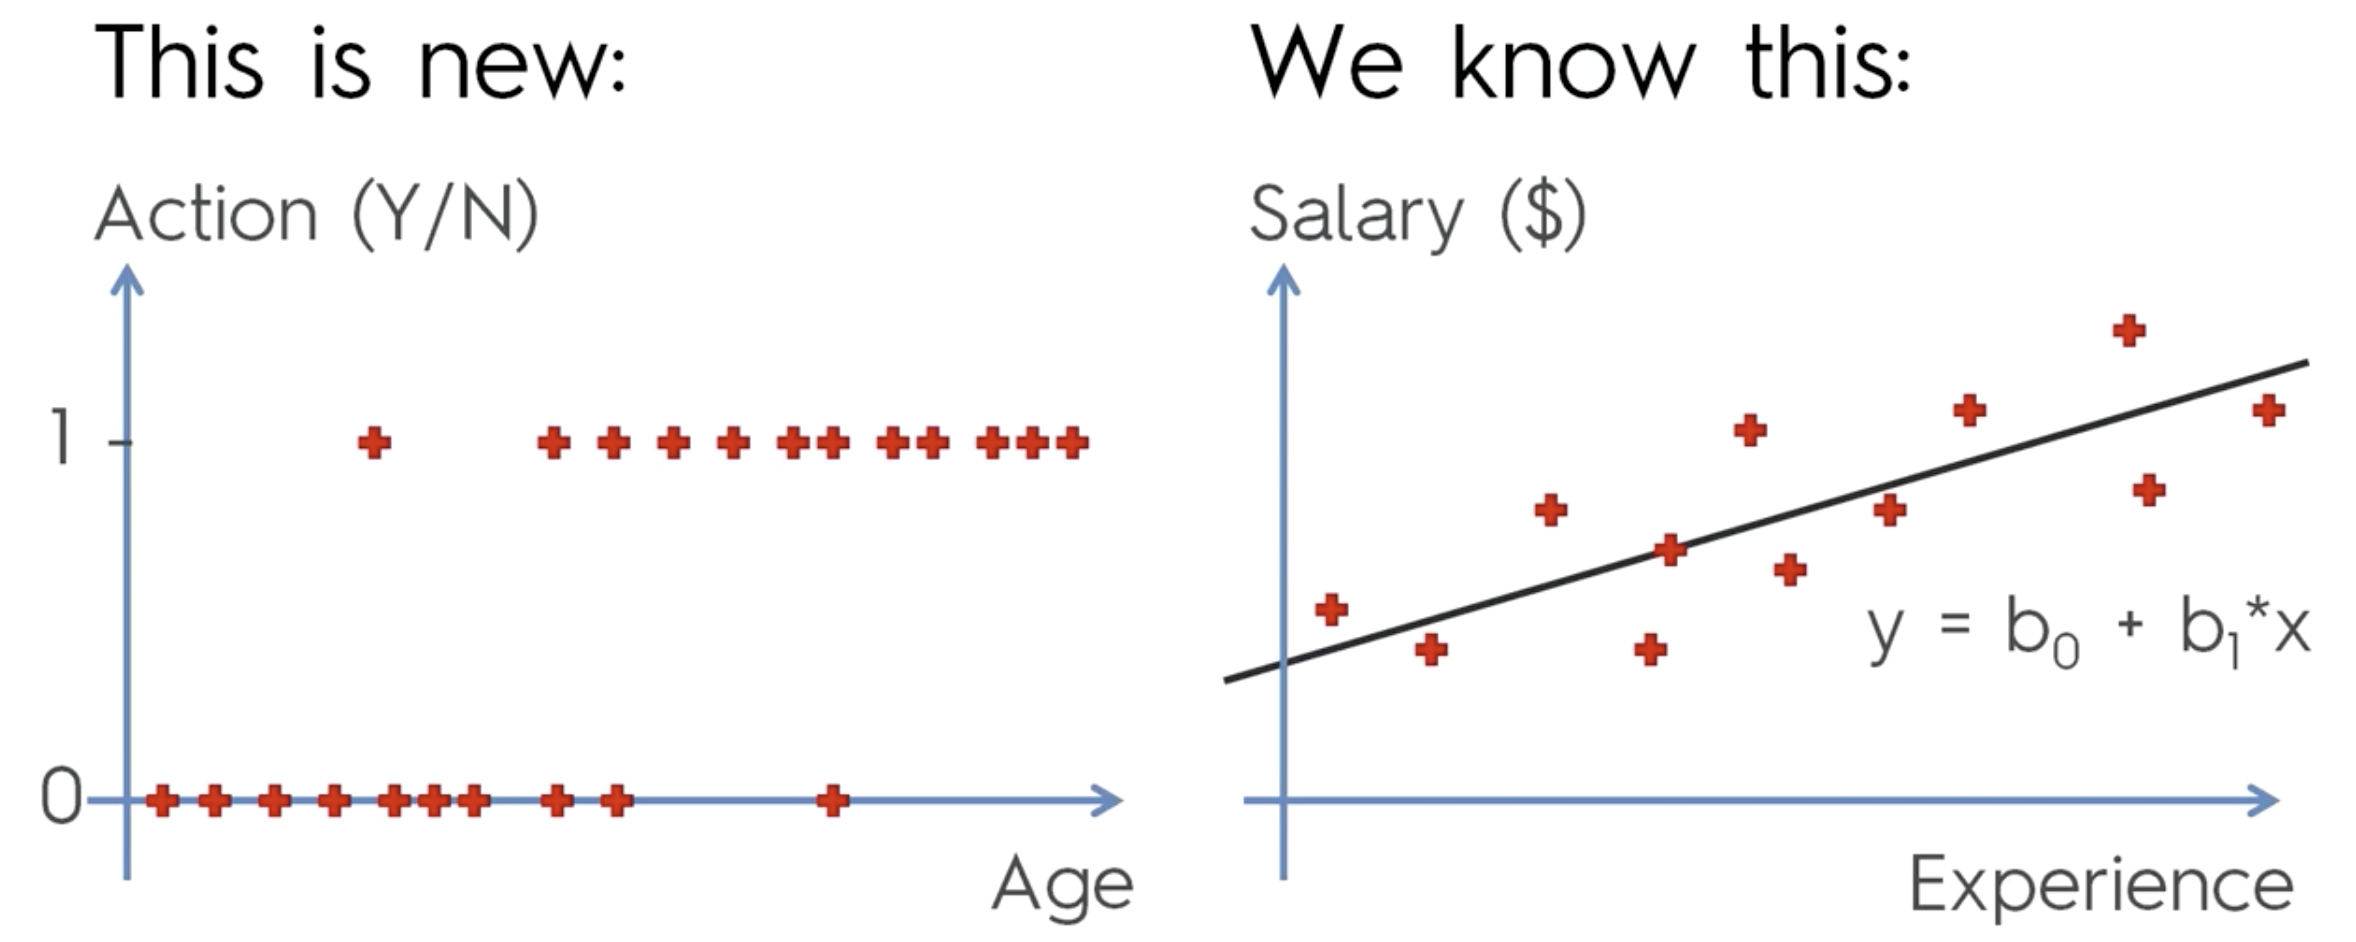

## 이메일 클릭을 할 사람과 안할 사람으로 분류할 것이다.

빨간점이 바로 데이터이며, 

액션의 0 과 1 이 바로 레이블이다. 

레이블이 있다는것은, 수퍼바이저드 러닝 이라는 뜻

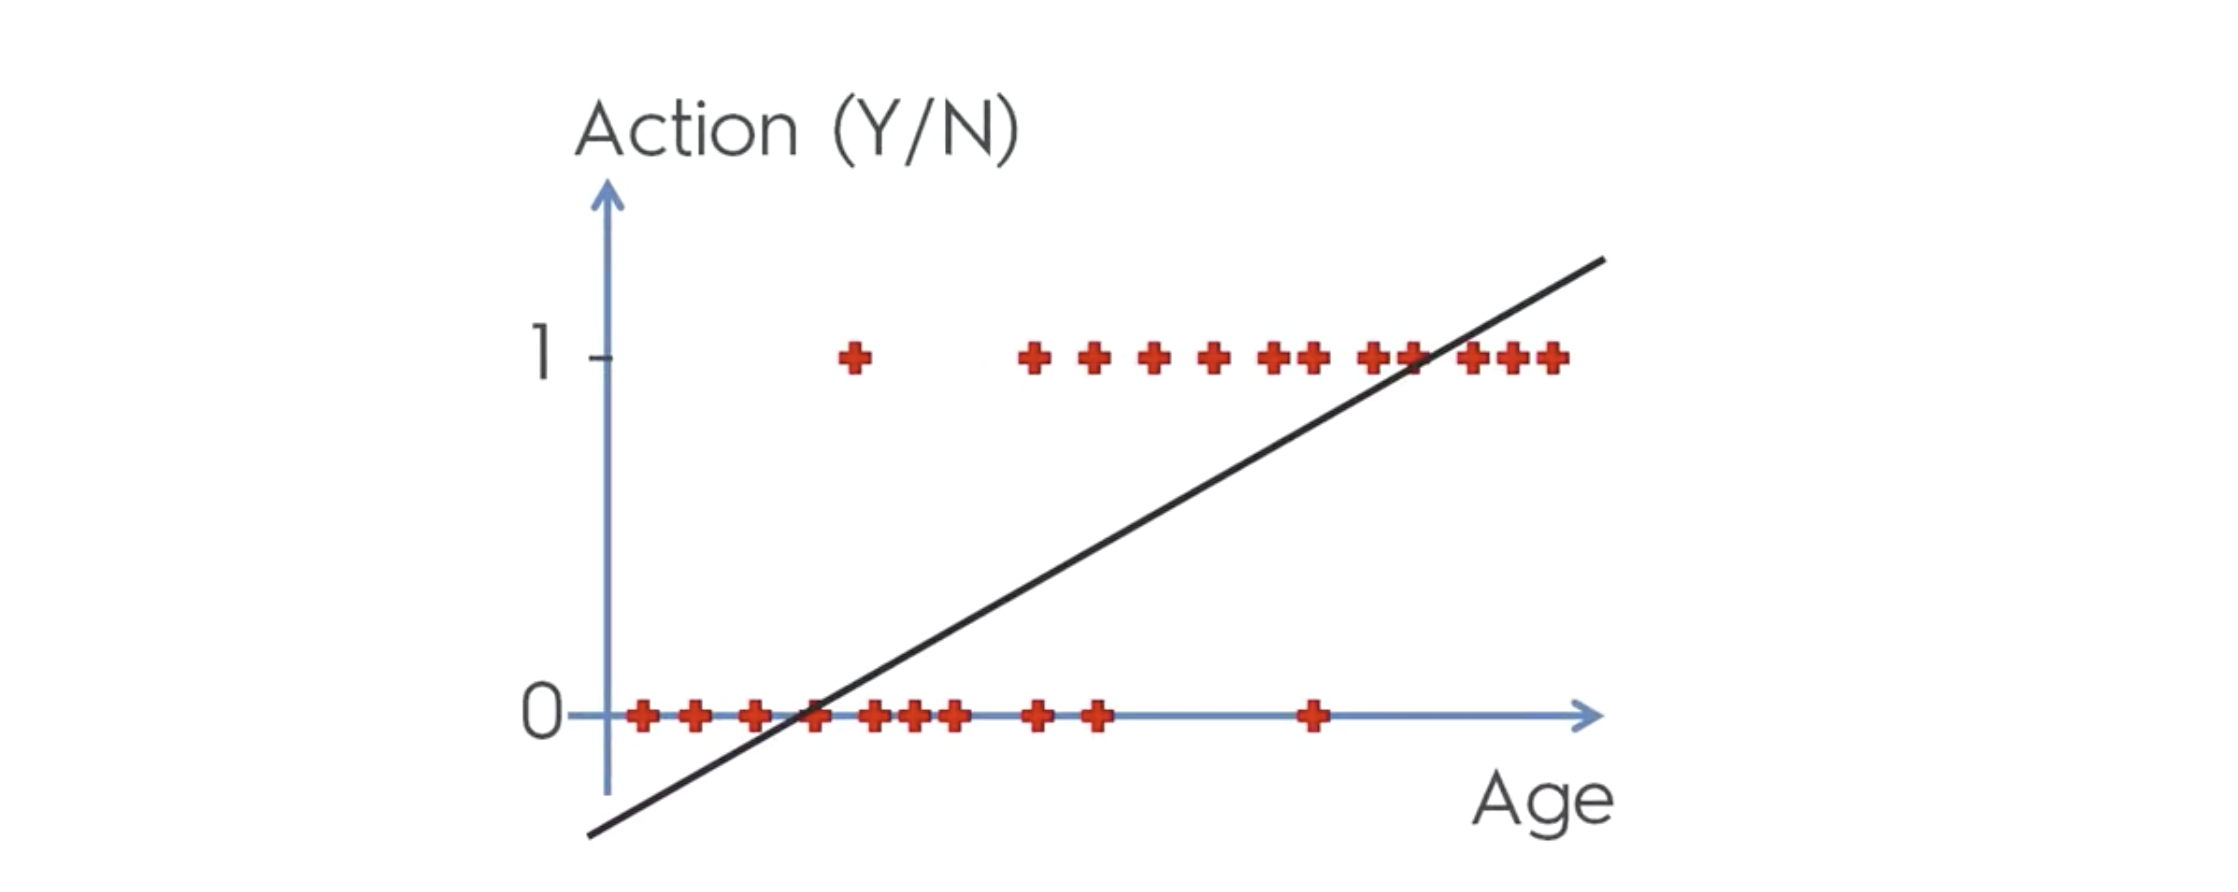

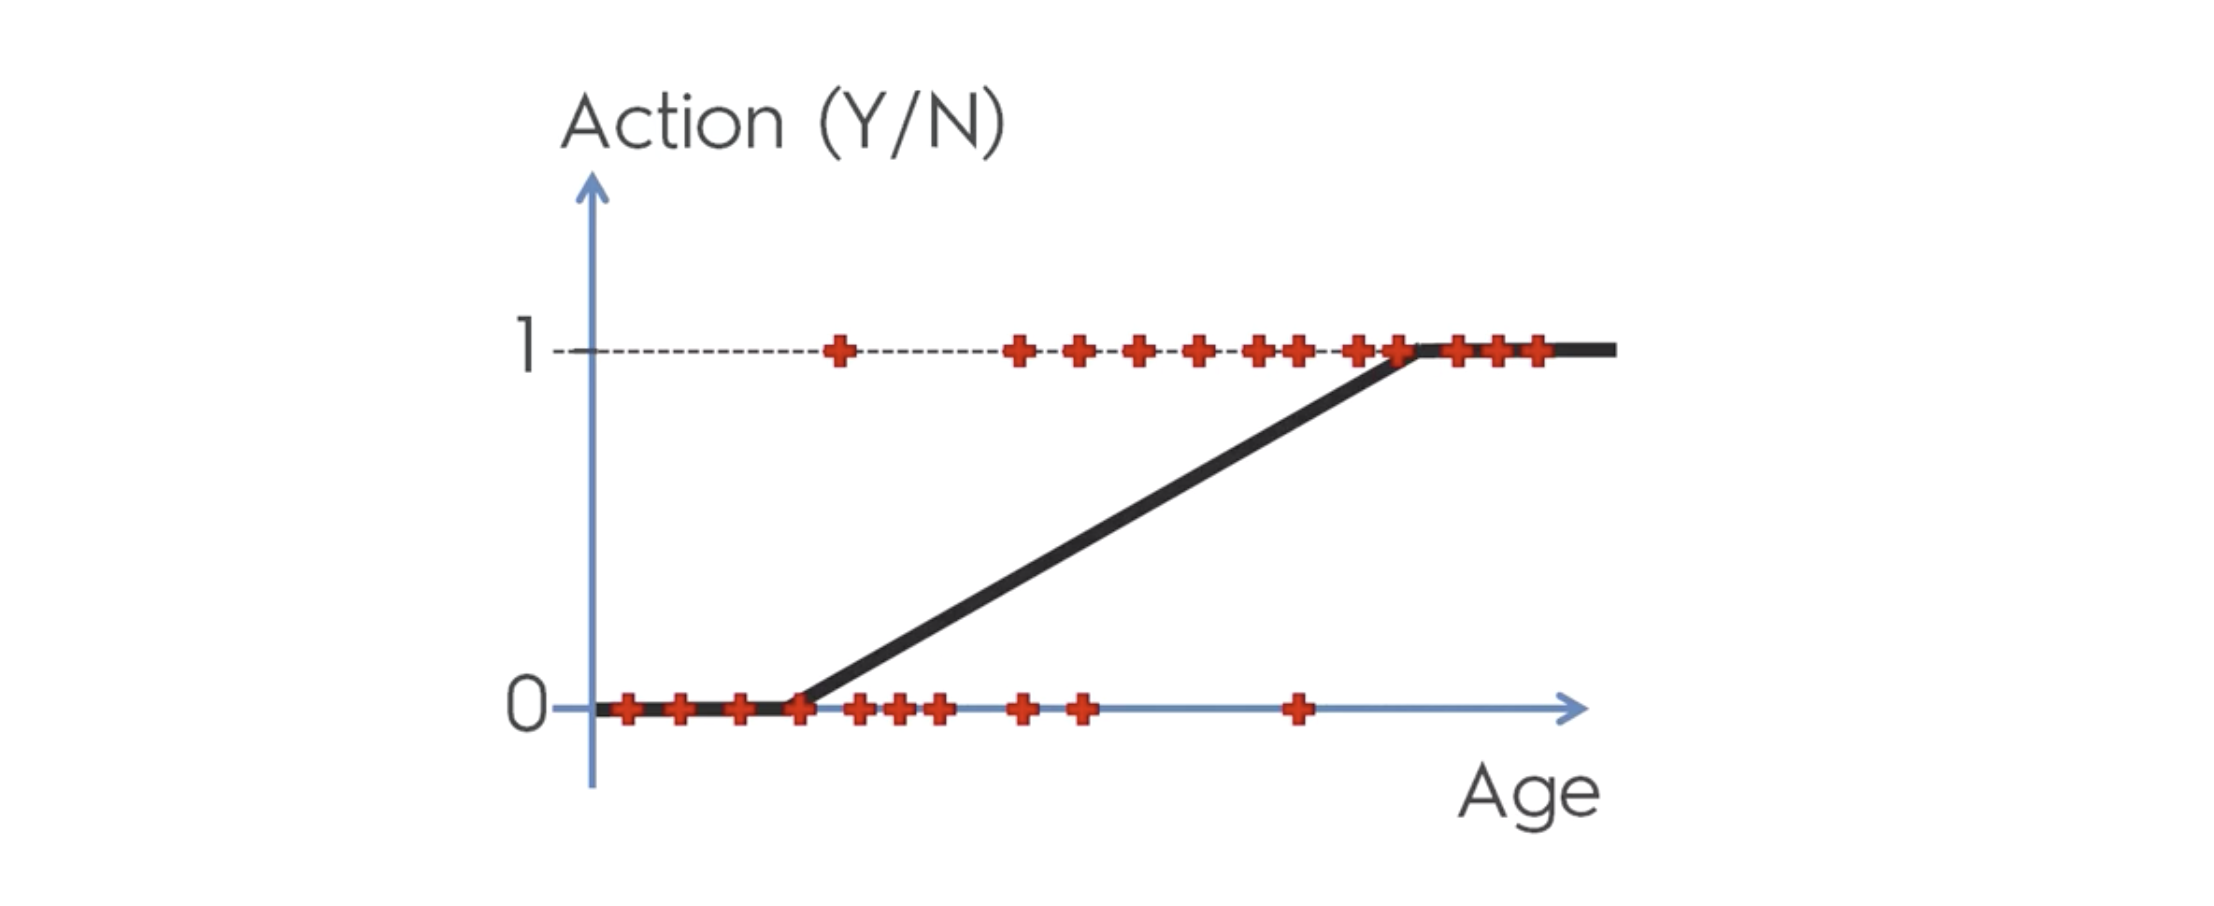

### 이렇게 비슷하게 생긴 함수가 이미존재한다. 이름은 sigmoid function

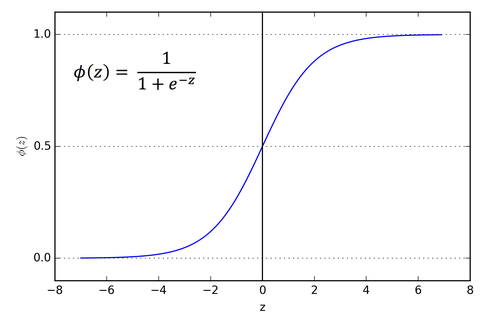

## 따라서 리니어 리그레션 식을, y 값을 시그모이드에 대입해서, 일차방정식으로 만들면 다음과 같아진다.

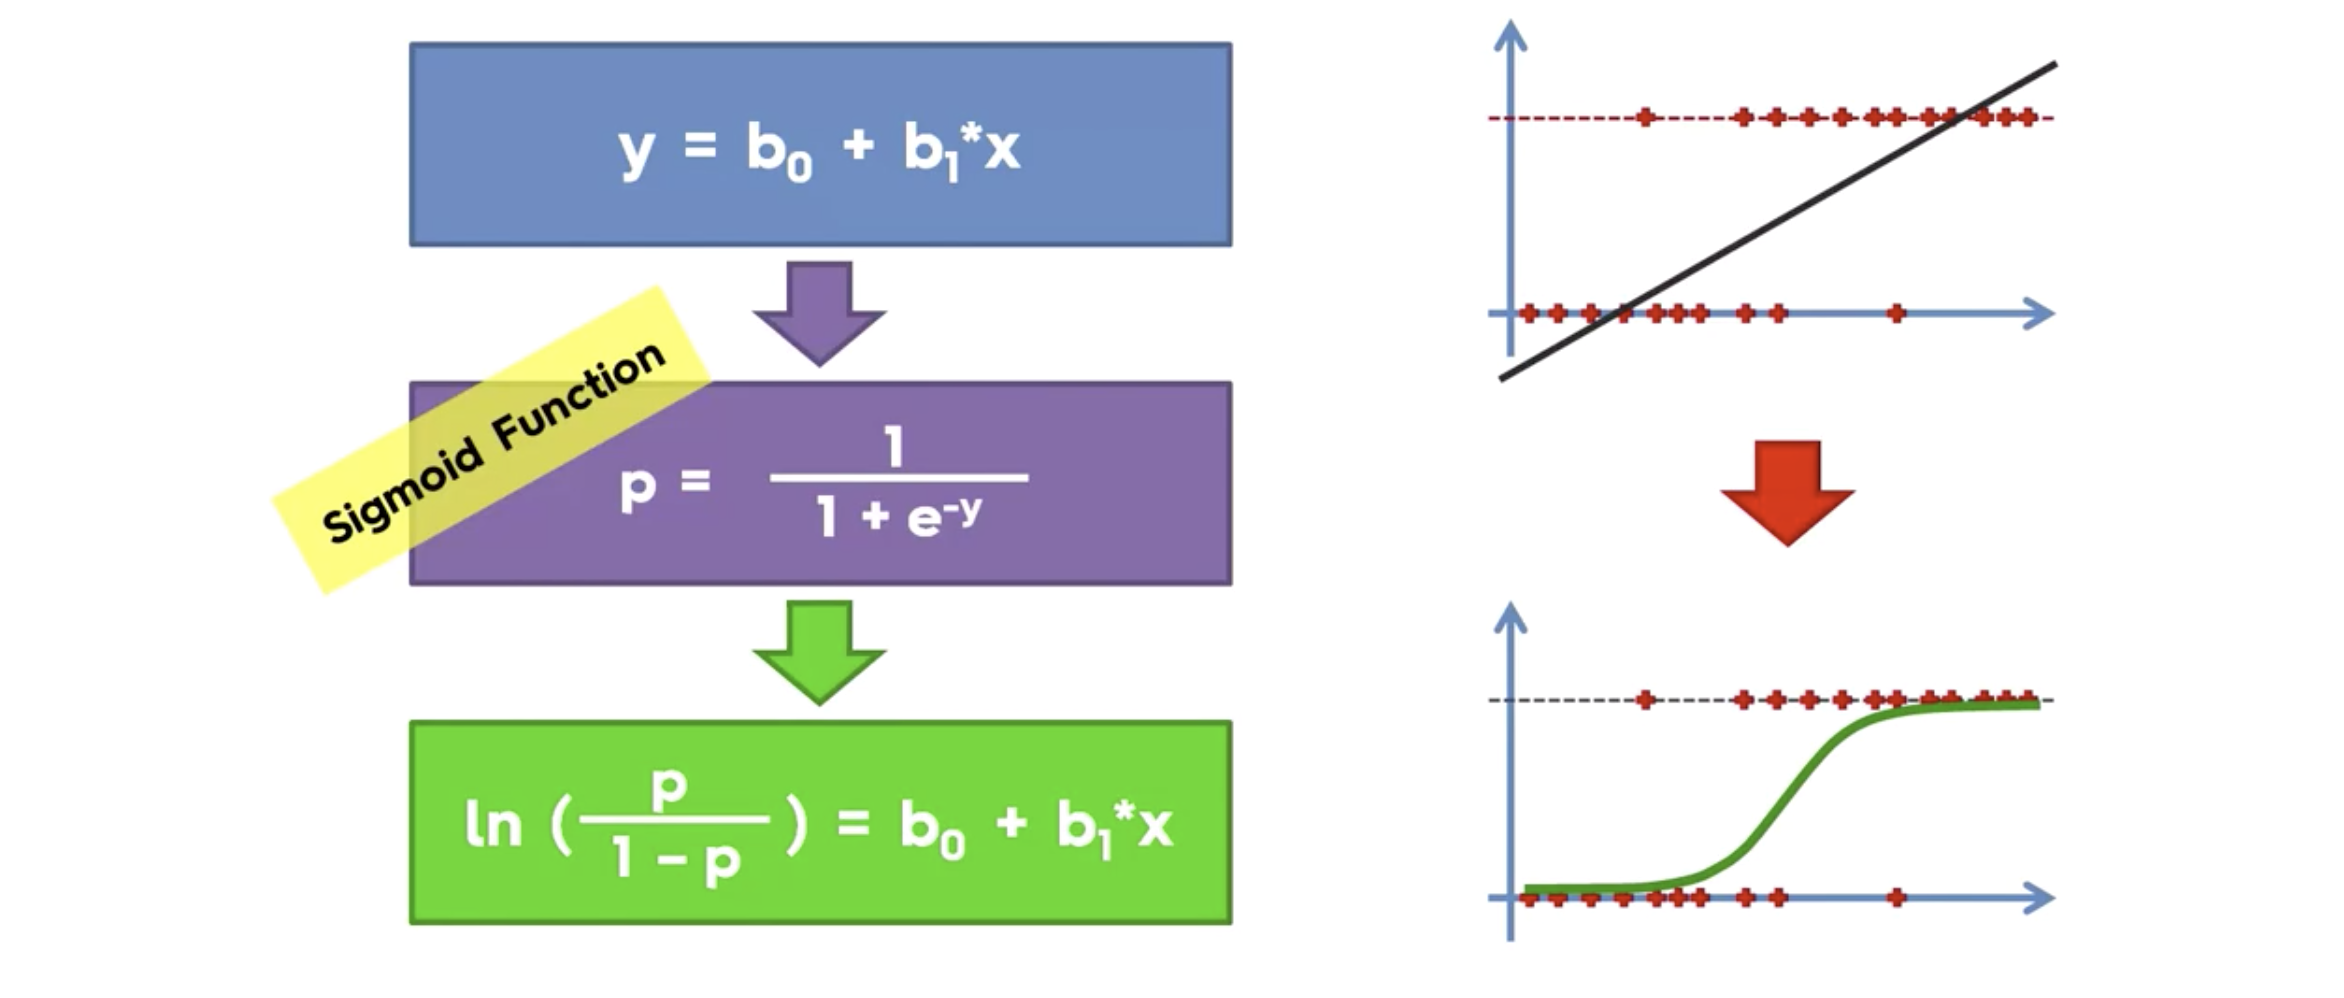

# 위와 같은 식을 가진 regression 을, Logistic Regression이라 한다.

---

## 이를 가지고 두개의 클래스로 분류할 수 있다. 
( 클릭을 한다, 안한다 두개로) 확률로 나타낼 수 있게 되었다.

p는 확률값을 나타낸다.

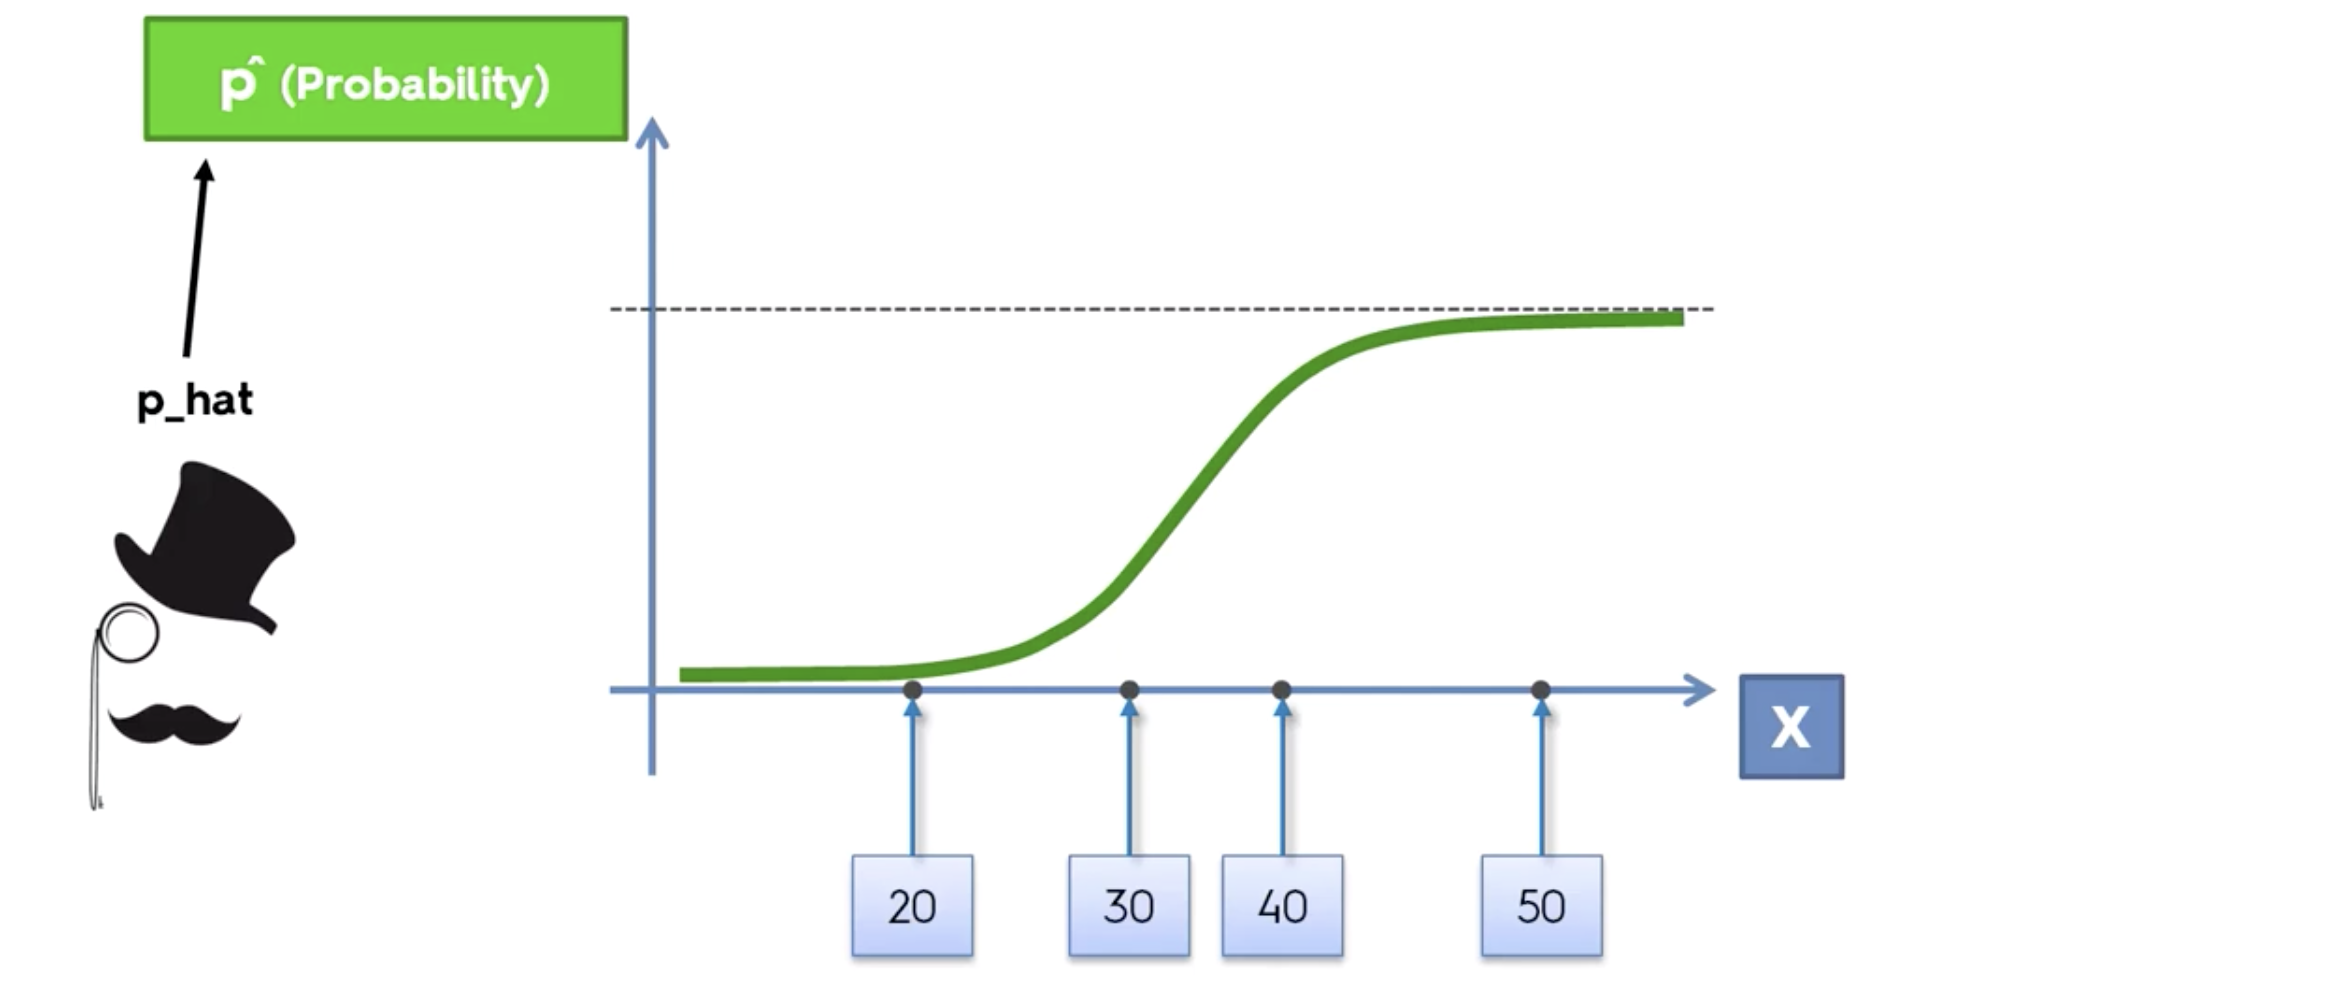

### 20대는 클릭할 확률이 0.7%,  40대는 85%, 50대는 99.4% 

이 확률값은, 위에서의 시그모이드 함수를 적용한 식을 통해 나온 값임을 기억한다.

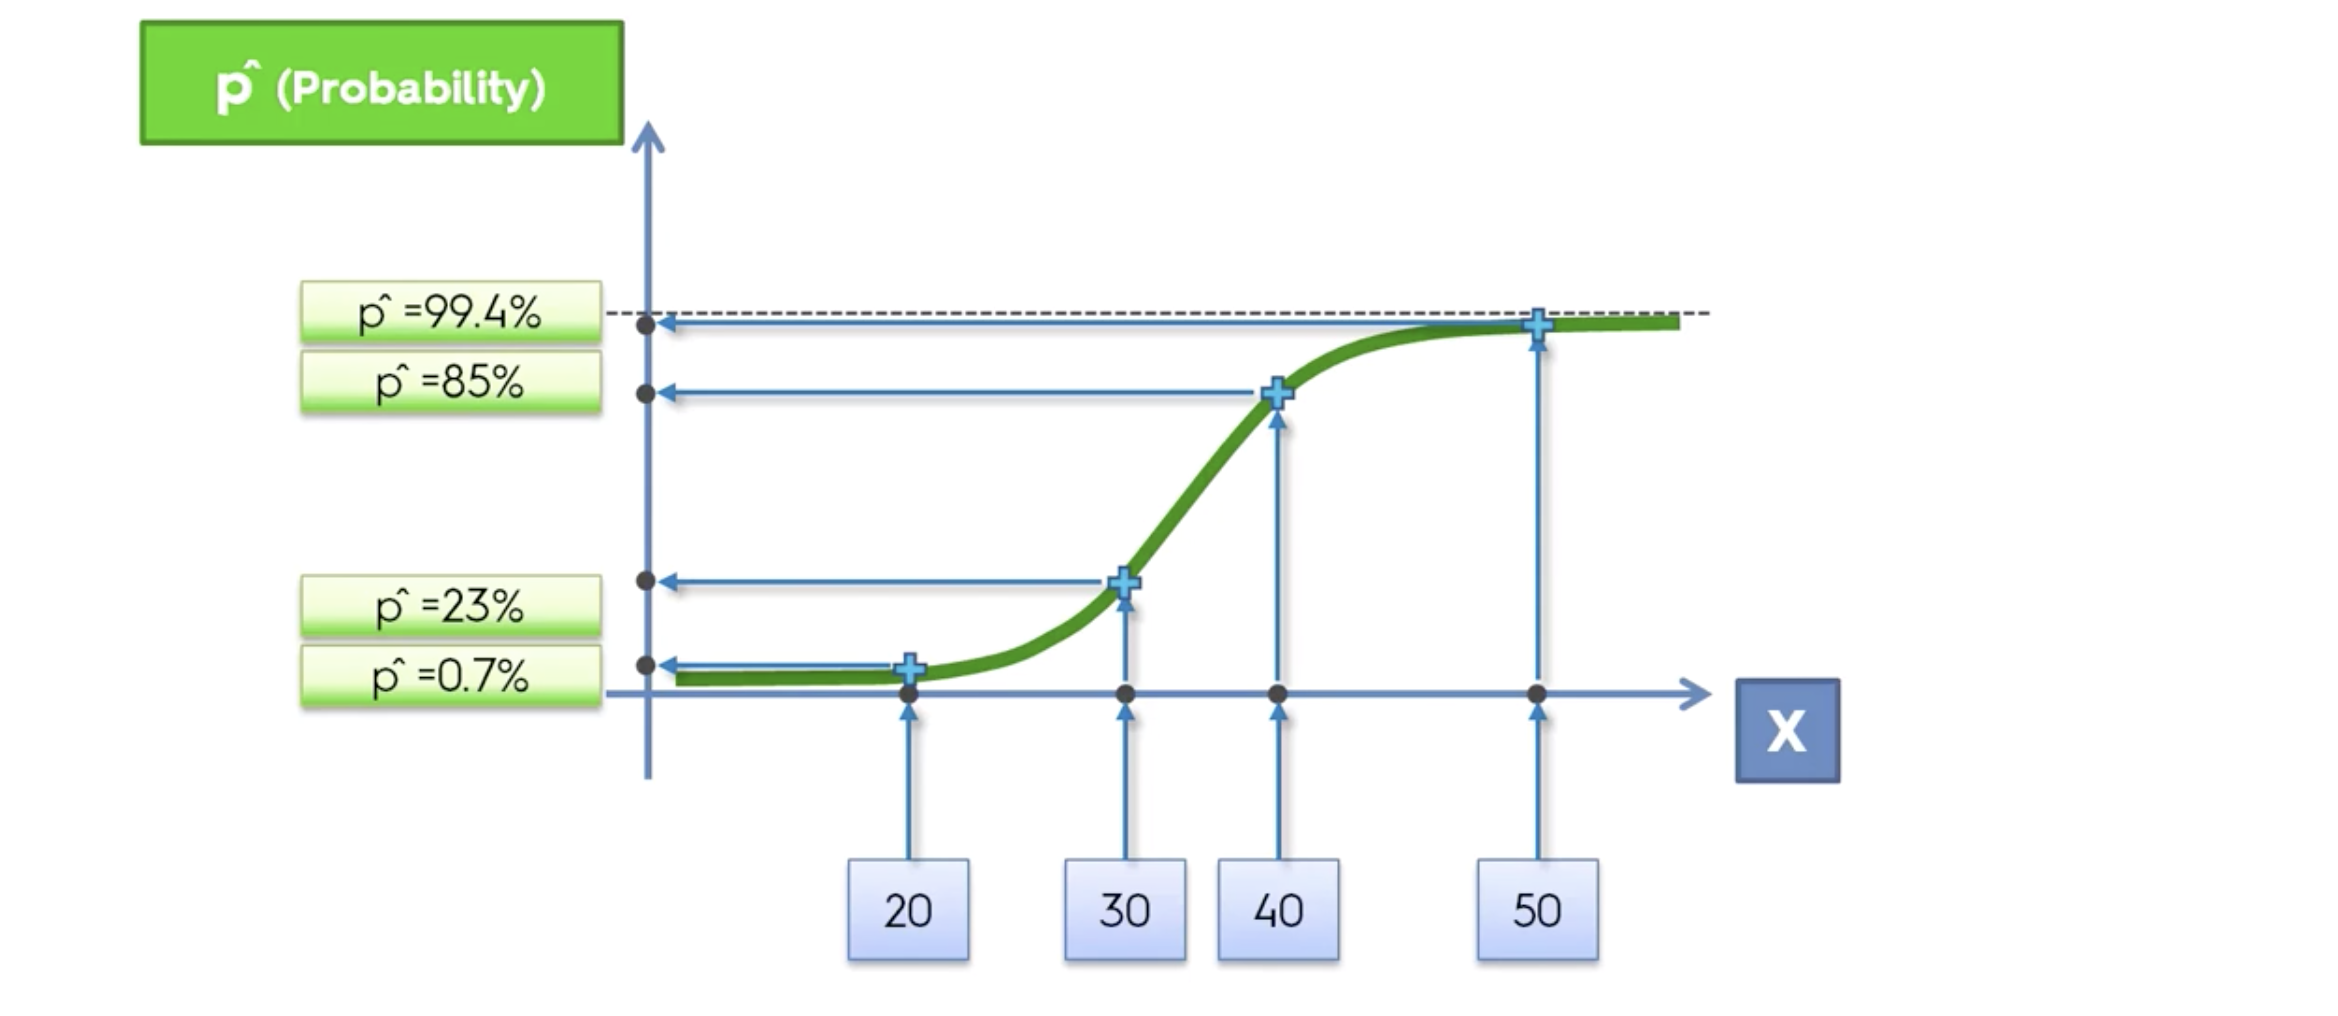

### 최종 예측값은, 0.5를 기준으로 두개의 부류로 나눈다. 그 값은 0 과 1 이다.

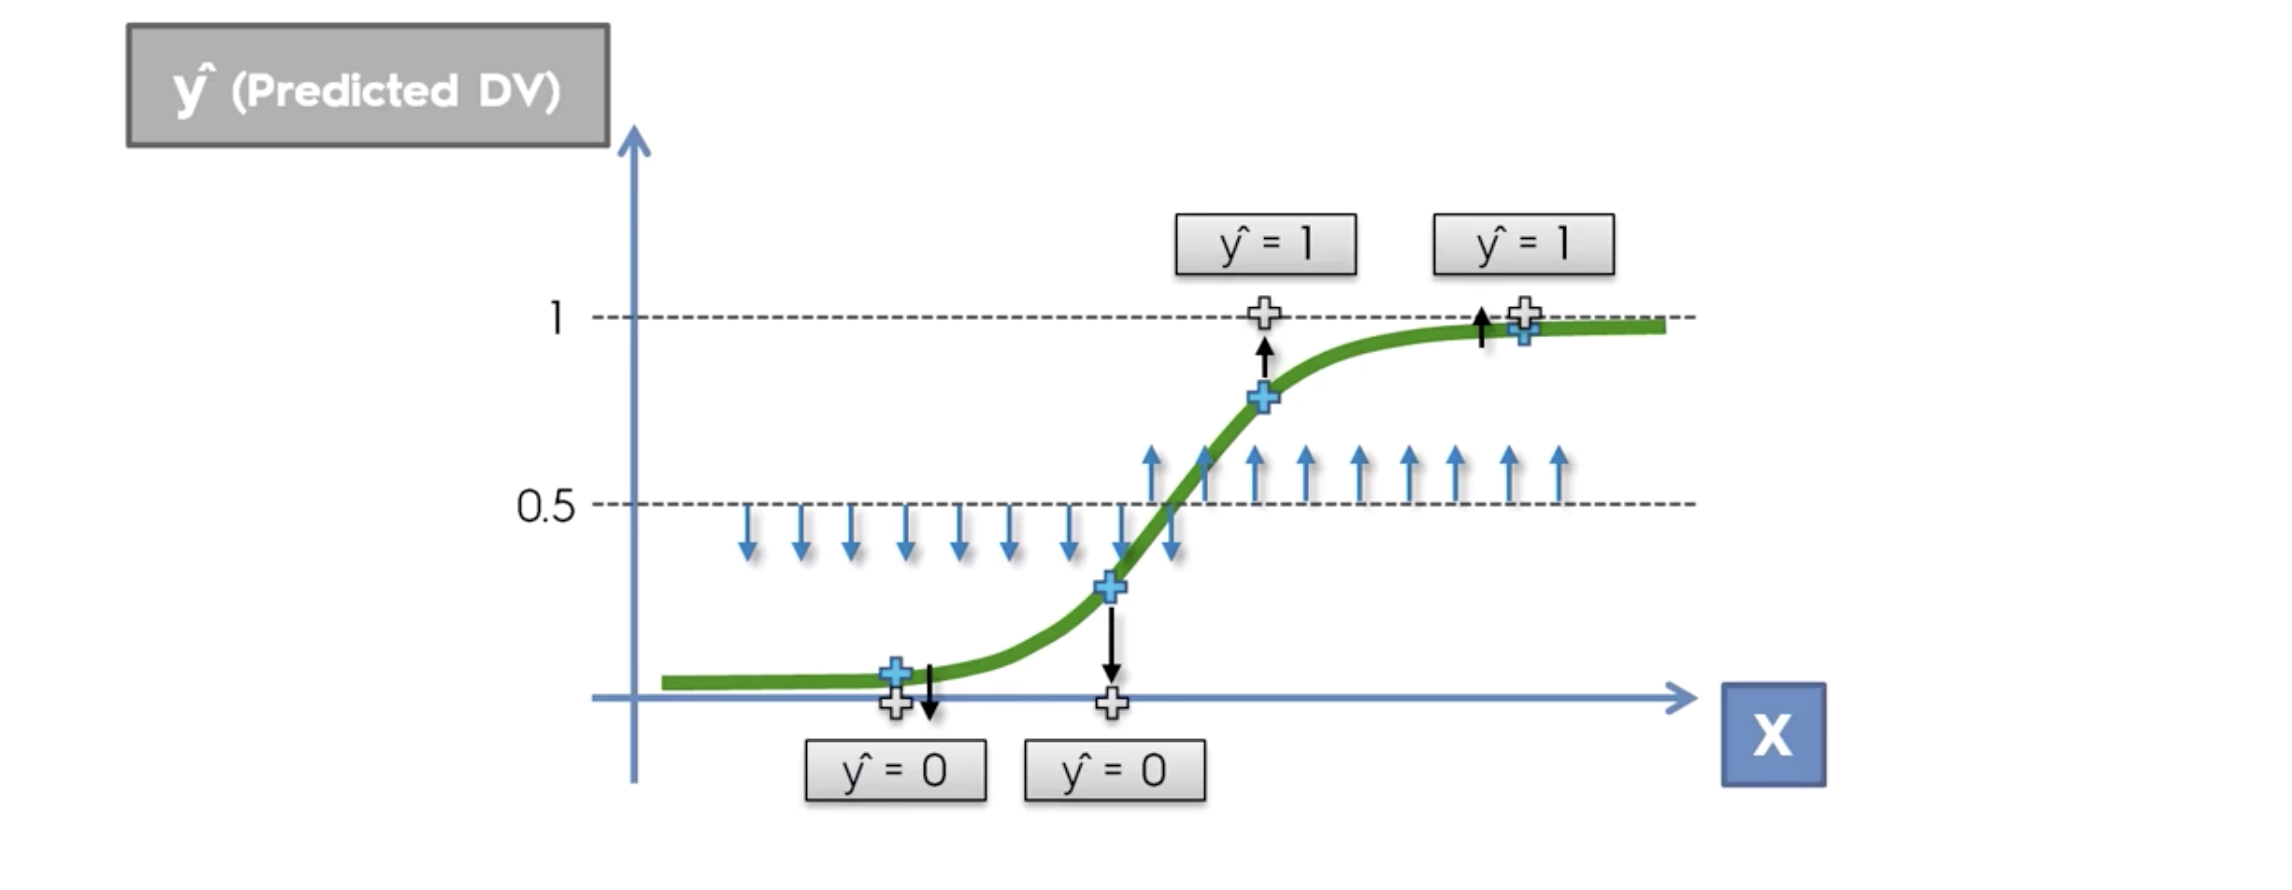

# lib와 데이터 로딩

In [26]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 나이와 연봉으로 분석해서, 물건을 구매할지 안할지를 분류하자!!

- 어떤 고객이 구매할 가능성이 높은지 예측
- 고객 세분화 : 나이, 성별, 연봉에 따른 구매 패턴 분석
- 마케팅 타겟팅 : 구매 가능성 높은 고객군 식별

### 데이터 : 마케팅/광고 캠페인 반응 데이터
- User ID: 고객 ID
- Gender: 성별 (Male/Female)
- Age: 나이
- EstimatedSalary: 추정 연봉
- Purchased: 구매 여부 (0=구매 안 함, 1=구매함)

In [27]:
data_path = 'datas_ml/Social_Network_Ads.csv'
df = pd.read_csv(data_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [29]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [30]:
y = df['Purchased']


In [31]:
# 0 : 미구매, 1 : 구매
y.unique()

array([0, 1])

In [32]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [33]:
X = df[['Gender', 'Age', 'EstimatedSalary']]

In [34]:
X

,Gender,Age,EstimatedSalary
0,Male,19,19000
1,Male,35,20000
2,Female,26,43000
3,Female,27,57000
4,Male,19,76000
...,...,...,...
395,Female,46,41000
396,Male,51,23000
397,Female,50,20000
398,Male,36,33000


In [35]:
X['Gender'].nunique()

2

In [36]:
X['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [37]:
X['Gender'].value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

In [38]:
def get_gender(gender):
    if gender == "Male":
        return 0
    else :
        return 1

In [39]:
# X['Gender'].apply(get_gender)
X['Gender'] = X['Gender'].apply(get_gender)

C:\Users\magpi\AppData\Local\Temp\ipykernel_1484\1198891261.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Gender'] = X['Gender'].apply(get_gender)


In [40]:
X.head()

,Gender,Age,EstimatedSalary
0,0,19,19000
1,0,35,20000
2,1,26,43000
3,1,27,57000
4,0,19,76000


In [41]:
X['Gender'].value_counts()

Gender
1    204
0    196
Name: count, dtype: int64

# Feature scaling

In [42]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [43]:
X_scaler = StandardScaler()

In [44]:
X_scaled = X_scaler.fit_transform(X)
X_scaled

array([[-1.02020406, -1.78179743, -1.49004624],
       [-1.02020406, -0.25358736, -1.46068138],
       [ 0.98019606, -1.11320552, -0.78528968],
       ...,
       [ 0.98019606,  1.17910958, -1.46068138],
       [-1.02020406, -0.15807423, -1.07893824],
       [ 0.98019606,  1.08359645, -0.99084367]], shape=(400, 3))

# train, test 데이터 분할

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=7)

In [47]:
X_train.shape, y_train.shape

((300, 3), (300,))

In [48]:
X_test.shape, y_test.shape

((100, 3), (100,))

# 모델 학습

In [50]:
from sklearn.linear_model import LogisticRegression

In [51]:
# 빈 깡통 모델
classifier = LogisticRegression()

In [52]:
classifier.coef_

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [53]:
# 학습
classifier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [54]:
y_pred = classifier.predict(X_test)
y_pred

array([1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0])

In [56]:
classifier.coef_

array([[-0.06049657,  2.13723312,  1.17166628]])

## 테스트 평가

In [58]:
# 정확도 계산
(y_test == y_pred).sum() / len(y_test) * 100

np.float64(86.0)

- 정확도 86%

In [47]:
# 실제 1인데, 예측 1로 한것
# 실제 0인데, 예측 1으로 한것

# 실제 1인데, 예측 0으로 한것
# 실제 0인데, 예측 0으로 학것

# 이것을 컨퓨전 매트릭스(혼동행렬)

In [59]:
df_test = y_test.to_frame()
df_test['y_pred'] = y_pred
df_test


,Purchased,y_pred
265,1,1
65,0,0
120,0,0
132,0,0
378,1,1
...,...,...
288,0,1
66,0,0
303,1,0
165,0,0


# Confusion Matrix

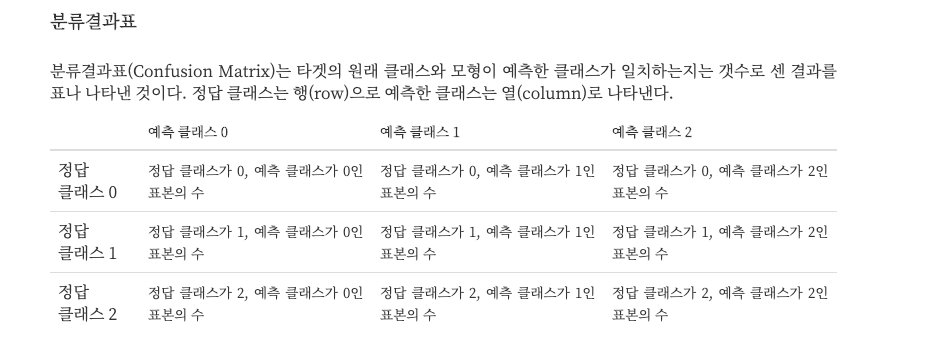

### 두 개의 클래스로 분류하는 경우는 아래와 같다.

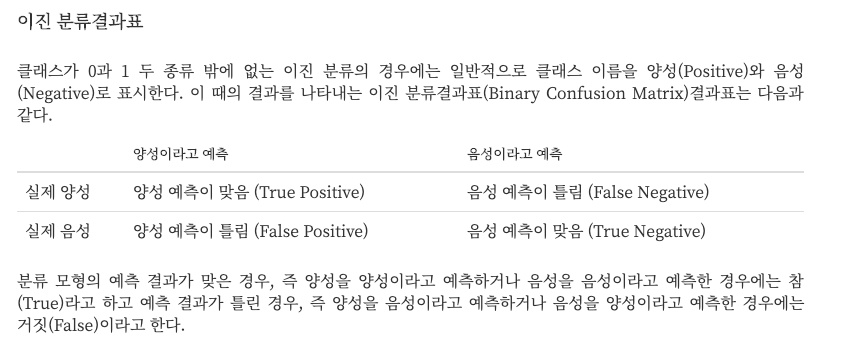

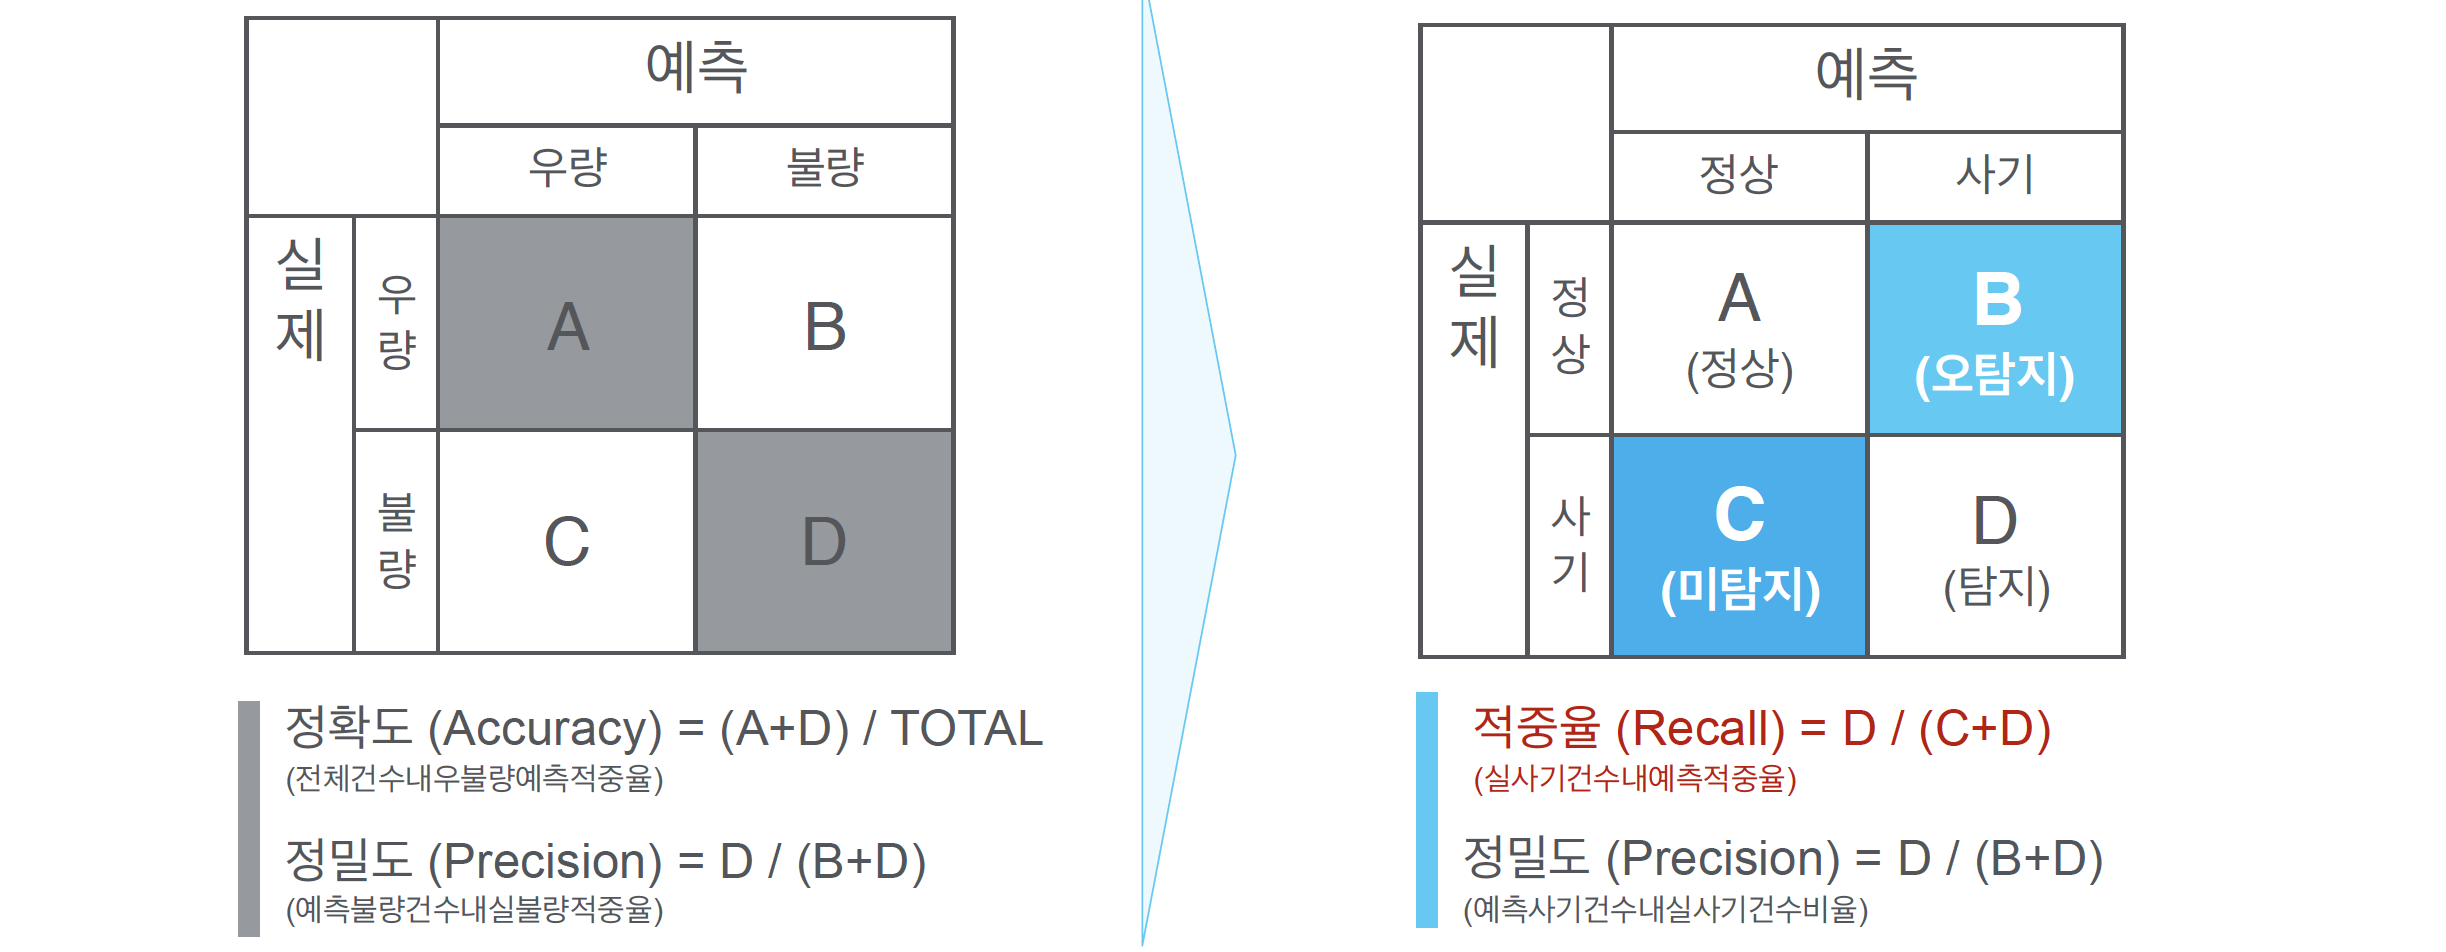

In [60]:
from sklearn.metrics import confusion_matrix

# confusion_matrix(실제값, 예측값)
confusion_matrix(y_test, y_pred)

array([[60,  8],
       [ 6, 26]])

In [61]:
cm = confusion_matrix(y_test, y_pred)

In [62]:
cm 

array([[60,  8],
       [ 6, 26]])

In [63]:
(60 + 26) / cm.sum()

np.float64(0.86)

## 정밀도, 재현율 한꺼번에 보기

In [64]:
from sklearn.metrics import classification_report, accuracy_score

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.86

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.91      0.88      0.90        68
           1       0.76      0.81      0.79        32

    accuracy                           0.86       100
   macro avg       0.84      0.85      0.84       100
weighted avg       0.86      0.86      0.86       100



## 모델 결과를 보고 전략을 짠다

In [65]:
import seaborn as sb

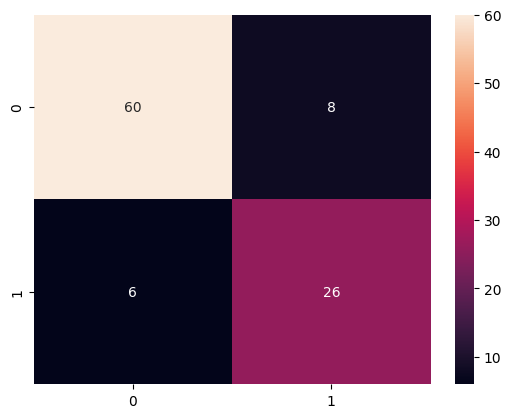

In [66]:
sb.heatmap(data=cm, annot=True)
plt.show()

- 구매를 할지 안할지 예측함
- 여기서, 정밀도, 재현율 중 어느것을 더 중요하게 생각하고, 성능을 높여야 할까?

- 우선적으로 

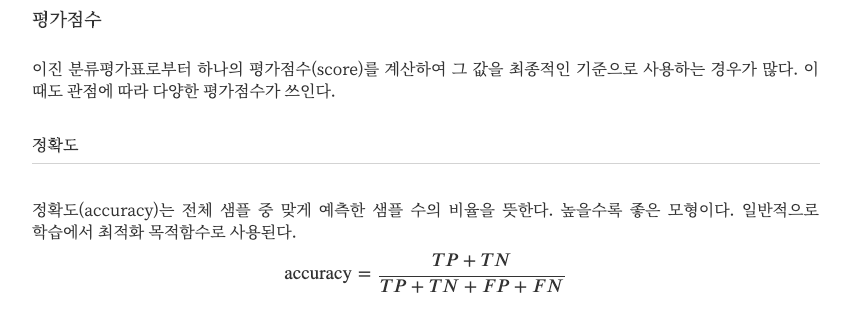

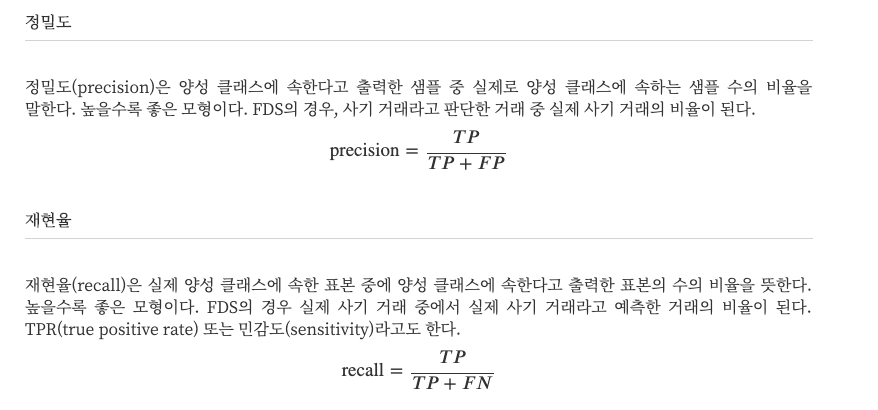

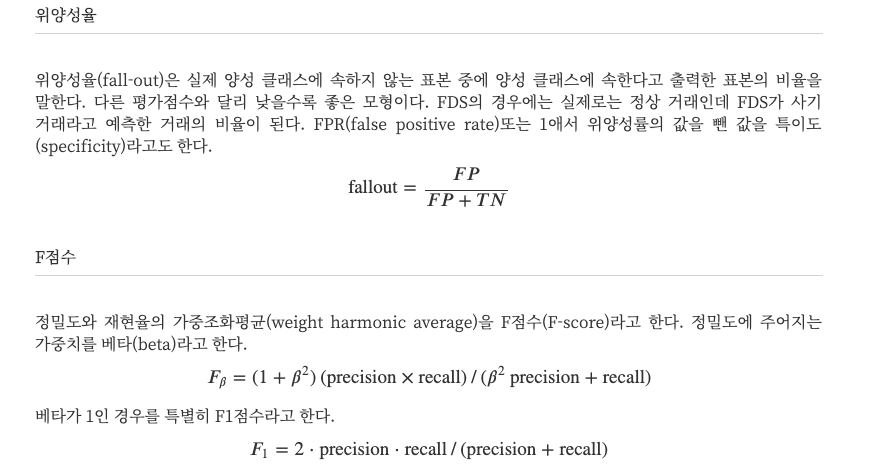

## Gender를 고정값으로 설정

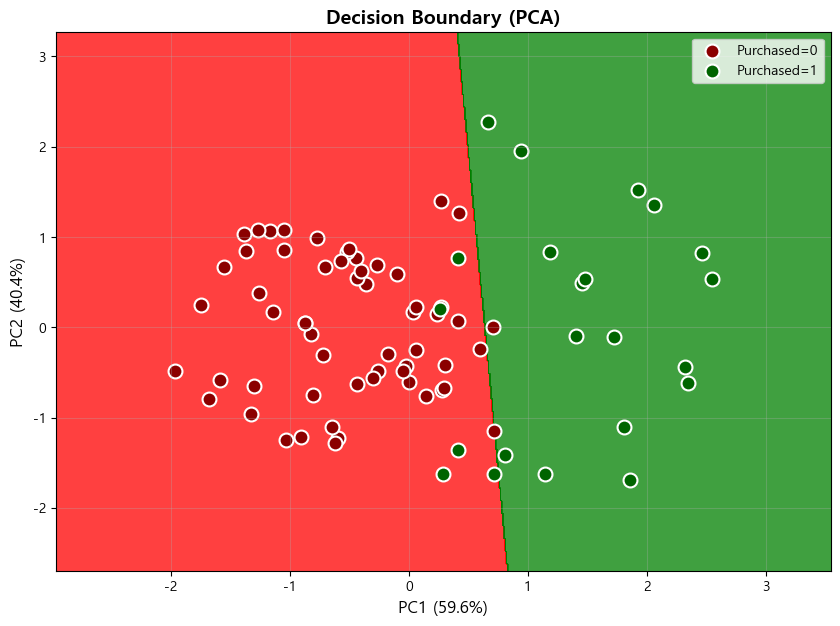

In [75]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# 3D → 2D 차원 축소
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test)

# 2D meshgrid
X1, X2 = np.meshgrid(
    np.arange(X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1, 0.01),
    np.arange(X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1, 0.01)
)

# 원래 3D 공간으로 역변환 후 예측
X_grid_2d = np.c_[X1.ravel(), X2.ravel()]
X_grid_3d = pca.inverse_transform(X_grid_2d)
predictions = classifier.predict(X_grid_3d).reshape(X1.shape)

# 시각화
plt.figure(figsize=(10, 7))
plt.contourf(X1, X2, predictions,
             alpha=0.75, cmap=ListedColormap(('red', 'green')))

for i, j in enumerate([0, 1]):
    plt.scatter(X_test_2d[y_test == j, 0], 
               X_test_2d[y_test == j, 1],
               c='darkred' if j == 0 else 'darkgreen',
               label=f'Purchased={j}',
               edgecolors='white',
               s=100,
               linewidth=1.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('Decision Boundary (PCA)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()